In [1]:
import custom.tools as tl
import custom.models as mod
import os
import torch 
import torch.nn as nn
from torch.utils.data import DataLoader, ConcatDataset
from tqdm import tqdm
import matplotlib.pyplot as plt

if torch.cuda.is_available():
    device = torch.device('cuda')
    torch.backends.cudnn.benchmark = True
else: device = torch.device('cpu')
print(f'Selected device: {device}')

Selected device: cuda


In [2]:
# local run
win_len = 80
win_stride = 66
data = tl.h5set('l1500mb_c.h5', win_len, win_stride, name='noise')
training = DataLoader(data, batch_size=1, num_workers=os.cpu_count()//2)
data_val = tl.h5set('l1500mb_c.h5', win_len, win_stride, name='injection')
validation = DataLoader(data_val, batch_size=1, num_workers=os.cpu_count()//2)

In [3]:
# model loading
gg = torch.load('../PSM3_42_continued.pt', weights_only=True)
ehi = mod.AEric(248, win_len, win_len*8, 8, 1).to(device)
ehi = torch.compile(ehi)
ehi.load_state_dict(gg['model_state_dict'])

<All keys matched successfully>

In [11]:
sample = next(iter(training)).to(device)

In [12]:
sample.shape

torch.Size([1, 248, 80])

In [13]:
# model output on sample
ehi.eval()
with torch.no_grad():
    with torch.autocast(device_type=str(device), dtype=torch.float16): out = ehi(sample)
sample = sample.to('cpu')
out = out.to('cpu')

In [14]:
out.shape

torch.Size([1, 248, 80])

In [15]:
sample.shape

torch.Size([1, 248, 80])

In [16]:
# full sample reconstruction (multivariate & univariate mode, have different dimensions arrangement, this is for multivariate)
sample_full = torch.hstack([sample[0, 0, :]] + [sample[0, i, -win_stride:] for i in range(1, sample.shape[1])])
out_full = torch.hstack([out[0, 0, :]] + [out[0, i, -win_stride:] for i in range(1, out.shape[1])])

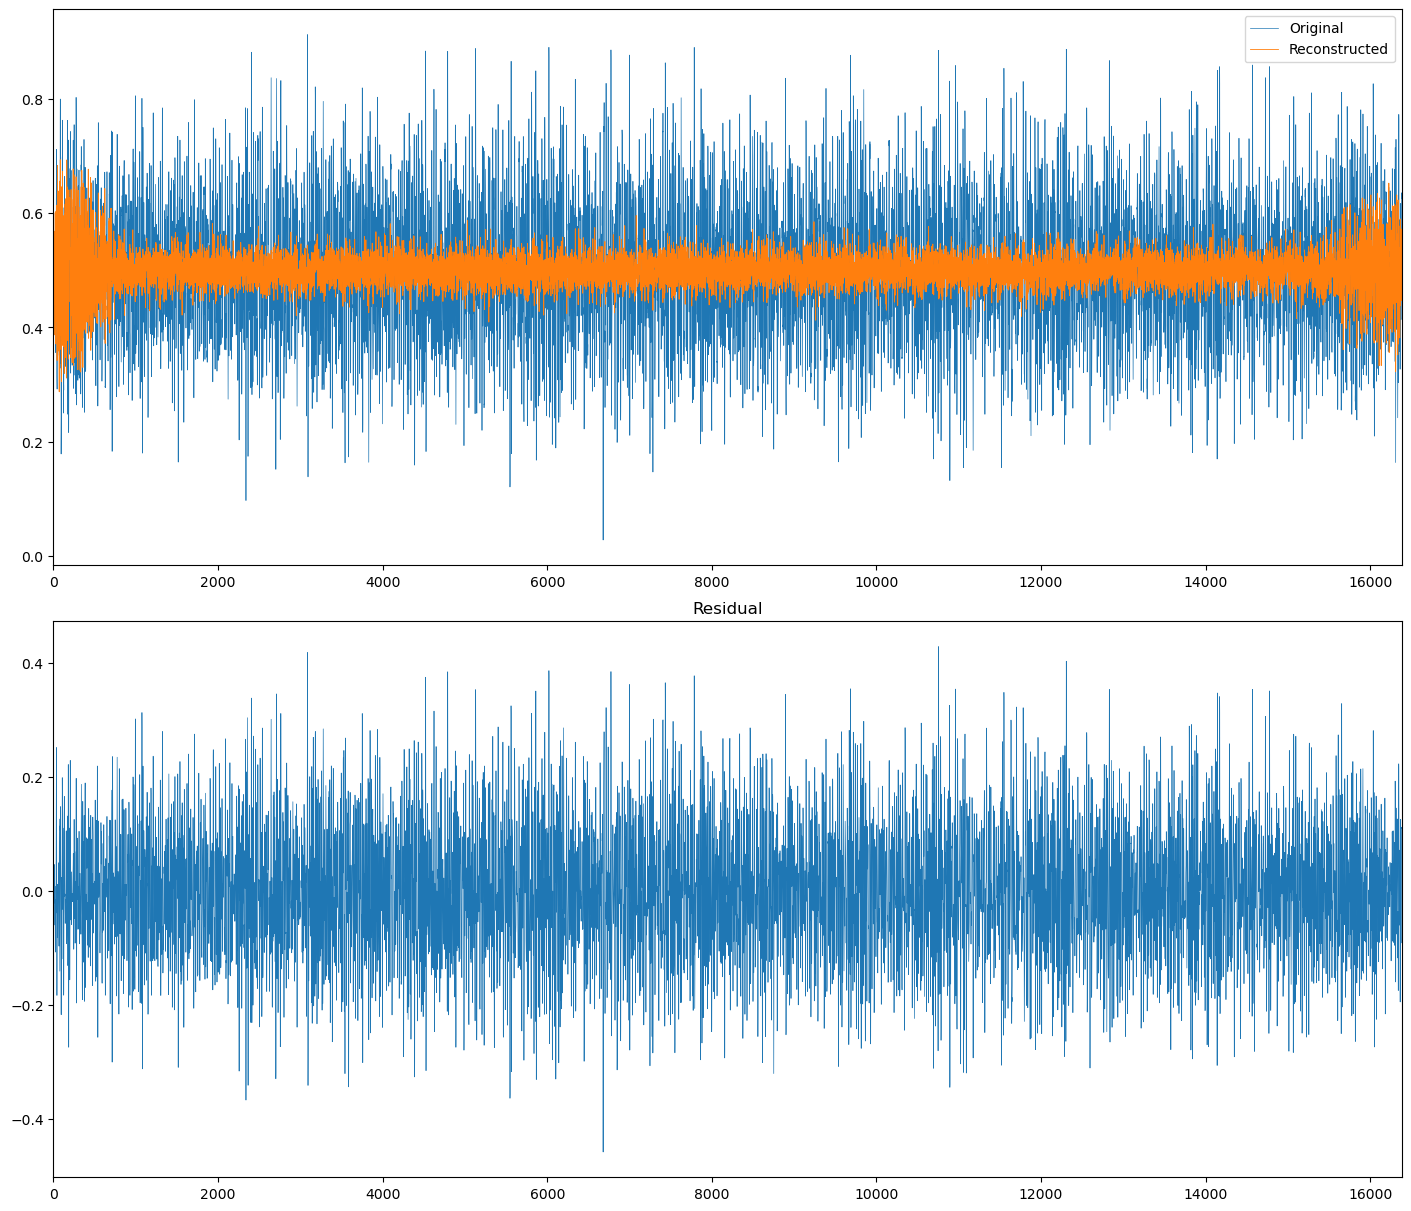

In [18]:
fig, ax = plt.subplots(2, 1, figsize=(14, 12), layout='constrained')
ax[0].plot(sample_full, lw=0.5, label='Original')
ax[0].plot(out_full, lw=.6, label='Reconstructed')
ax[0].legend()

ax[1].plot(sample_full - out_full, lw=.5)
ax[1].set_title('Residual')
for Ax in ax: Ax.set_xlim((0, len(sample_full)))
plt.show()